In [70]:
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.model_selection import train_test_split
import joblib
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [71]:
df = pd.read_csv("Telco_Customer_Dataset.csv")
df.drop("customerID",axis=1,inplace=True)

In [72]:
df['TotalCharges'] = df['TotalCharges'].replace({" ":'0.0'}).astype(float)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [73]:
print(df["Churn"].value_counts())
print(f"Class Imbalance Ratio : {df["Churn"].value_counts()[0]/df["Churn"].value_counts()[1]:.2f}:1")

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Class Imbalance Ratio : 2.77:1


C:\Users\Admin\AppData\Local\Temp\ipykernel_7556\469770732.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Class Imbalance Ratio : {df["Churn"].value_counts()[0]/df["Churn"].value_counts()[1]:.2f}:1")
C:\Users\Admin\AppData\Local\Temp\ipykernel_7556\469770732.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Class Imbalance Ratio : {df["Churn"].value_counts()[0]/df["Churn"].value_counts()[1]:.2f}:1")


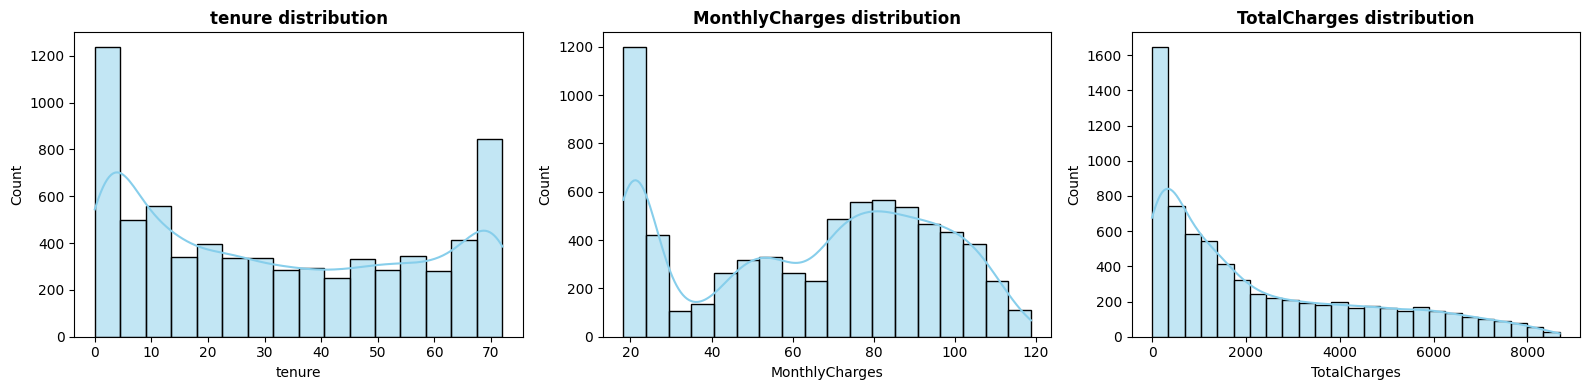

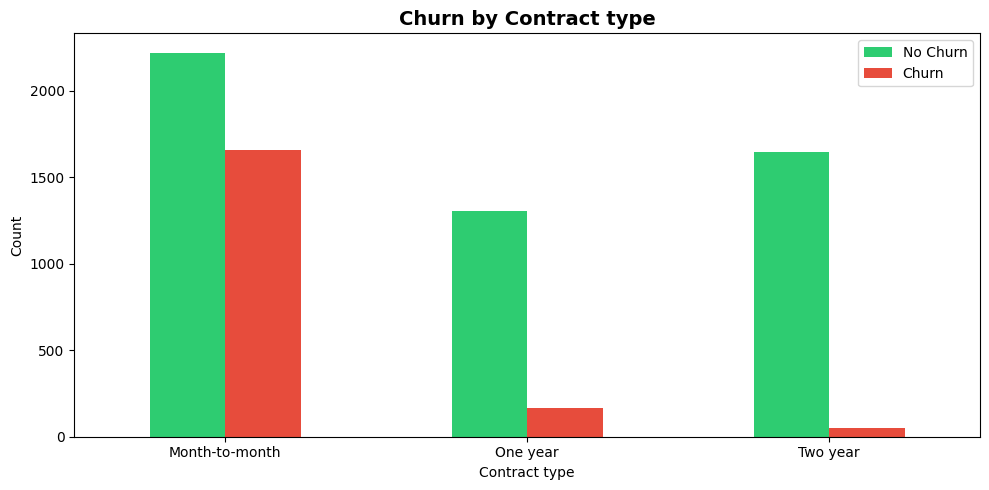

In [74]:
fig,axis = plt.subplots(1,3,figsize=(16,4))
for idx,col in enumerate(["tenure","MonthlyCharges","TotalCharges"]):
    sns.histplot(df[col],kde=True,ax=axis[idx],color="skyblue")
    axis[idx].set_title(f"{col} distribution",fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

fig,ax = plt.subplots(1,1,figsize=(10,5))
contract_churn = df.groupby(['Contract','Churn']).size().unstack(fill_value=0)
contract_churn.plot(kind='bar',stacked=False,ax=ax,color=['#2ecc71','#e74c3c'])
ax.set_title('Churn by Contract type',fontsize=14,fontweight='bold')
ax.set_xlabel('Contract type')
ax.set_ylabel("Count")
ax.legend(['No Churn','Churn'])
ax.set_xticklabels(ax.get_xticklabels(),rotation=0)
plt.tight_layout()
plt.show()

In [75]:
binary_cols = ['Partner','PhoneService','PaperlessBilling','Churn','Dependents']
for col in binary_cols:
    df[col] = np.where(df[col]=="Yes",1,0)
df['gender'] = np.where(df['gender']=="Male",1,0)  
categorical_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']  
encoders = {} 
for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

In [76]:
x = df.drop('Churn',axis=1)
y = df['Churn']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
5,0,0,0,0,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
6,1,0,0,1,22,1,2,1,0,2,0,0,2,0,0,1,1,89.10,1949.40,0
7,0,0,0,0,10,0,1,0,2,0,0,0,0,0,0,0,3,29.75,301.90,0
8,0,0,1,0,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
9,1,0,0,1,62,1,0,0,2,2,0,0,0,0,1,0,0,56.15,3487.95,0


In [77]:
smote = SMOTE(random_state=42)
x_train_balanced,y_train_balanced =smote.fit_resample(x_train,y_train)
dict(y_train.value_counts())

{0: np.int64(4139), 1: np.int64(1495)}

In [78]:
dict(y_train_balanced.value_counts())

{0: np.int64(4139), 1: np.int64(4139)}

In [79]:
xgb_model = XGBClassifier(n_estimators=100,max_depth=5,learning_rate=0.1,random_state=42)
xgb_model.fit(x_train_balanced,y_train_balanced)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [82]:
y_train_pred = xgb_model.predict(x_train)
y_test_pred = xgb_model.predict(x_test)
train_acc = metrics.accuracy_score(y_train,y_train_pred)
test_acc = metrics.accuracy_score(y_test,y_test_pred)

In [83]:
print("Training Accuracy : ",train_acc)
print("Test Accuracy : ",test_acc)

Training Accuracy :  0.8258785942492013
Test Accuracy :  0.7686302342086586


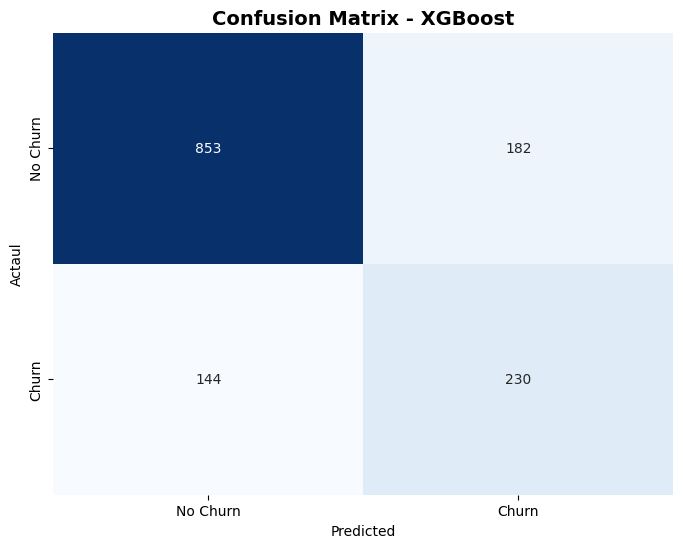

In [84]:
cm = metrics.confusion_matrix(y_test,y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,xticklabels=['No Churn','Churn'],yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix - XGBoost',fontsize=14,fontweight='bold')
plt.ylabel('Actaul')
plt.xlabel("Predicted")
plt.show()

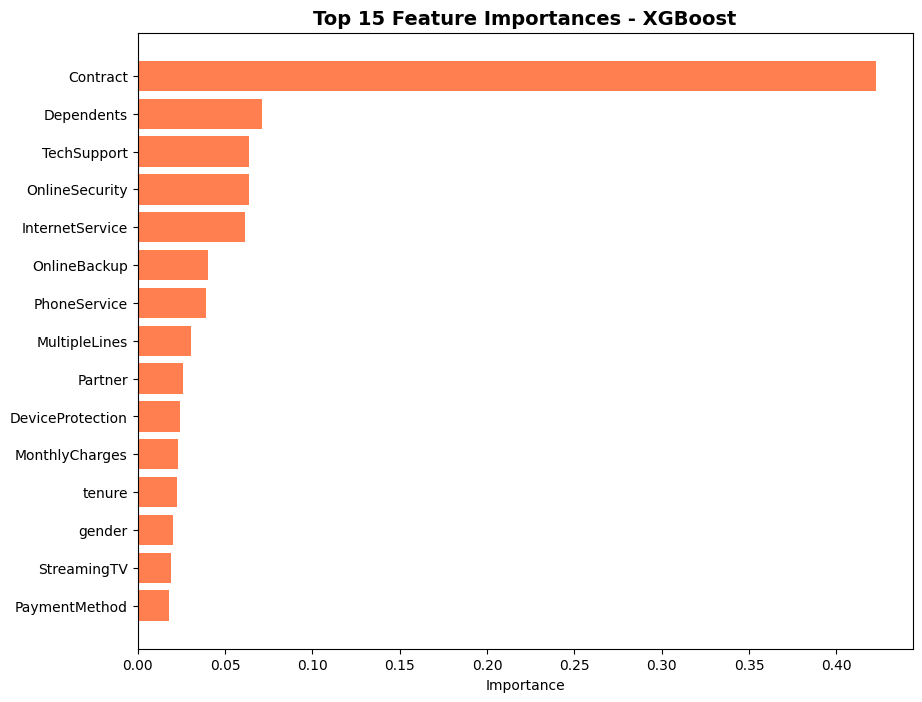

In [85]:
feature_importance = pd.DataFrame({
    'Feature':x.columns,
    'Importance':xgb_model.feature_importances_
}).sort_values('Importance',ascending=False)
feature_importance.head(10)
plt.figure(figsize=(10,8))
plt.barh(feature_importance['Feature'][:15],feature_importance['Importance'][:15],color='coral')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - XGBoost',fontsize=14,fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

In [86]:
joblib.dump(xgb_model,'Customer_Churn_Prediction.pkl')
joblib.dump(encoders,'Churn_Encoders.pkl')

['Churn_Encoders.pkl']